In [1]:
import numpy as np
import matplotlib.pyplot as plt

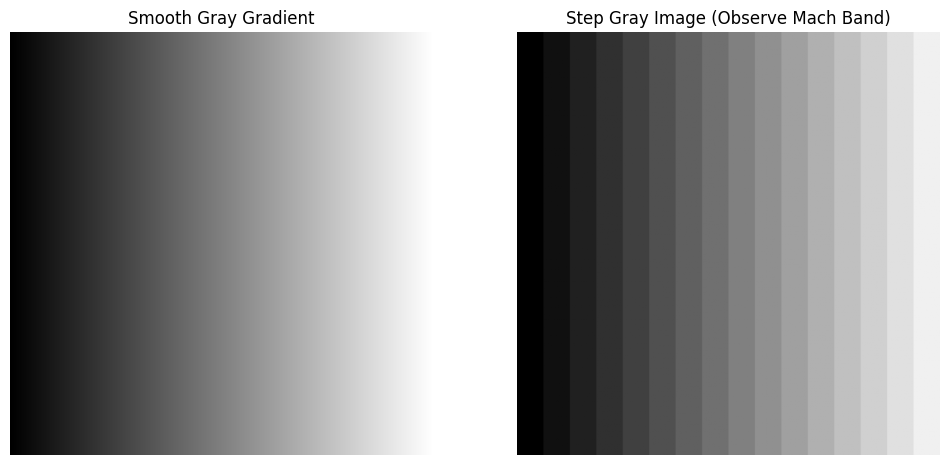

In [2]:
# Project 1 Grey Image

height, width = 256, 256   # 图像尺寸

# 每一列的灰度值从0到255线性变化
smooth_image = np.tile(np.arange(width, dtype=np.uint8), (height, 1))

# 每个 band 宽16像素，灰度值递增16
step_size = 16
bands = width // step_size
step_image = np.zeros((height, width), dtype=np.uint8)

for i in range(bands):
    step_image[:, i*step_size:(i+1)*step_size] = i * step_size

# 显示图像
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(smooth_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Smooth Gray Gradient')
axes[0].axis('off')

axes[1].imshow(step_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Step Gray Image (Observe Mach Band)')
axes[1].axis('off')

plt.show()

dict_keys(['__header__', '__version__', '__globals__', 'data'])
Image shape: (361, 361)


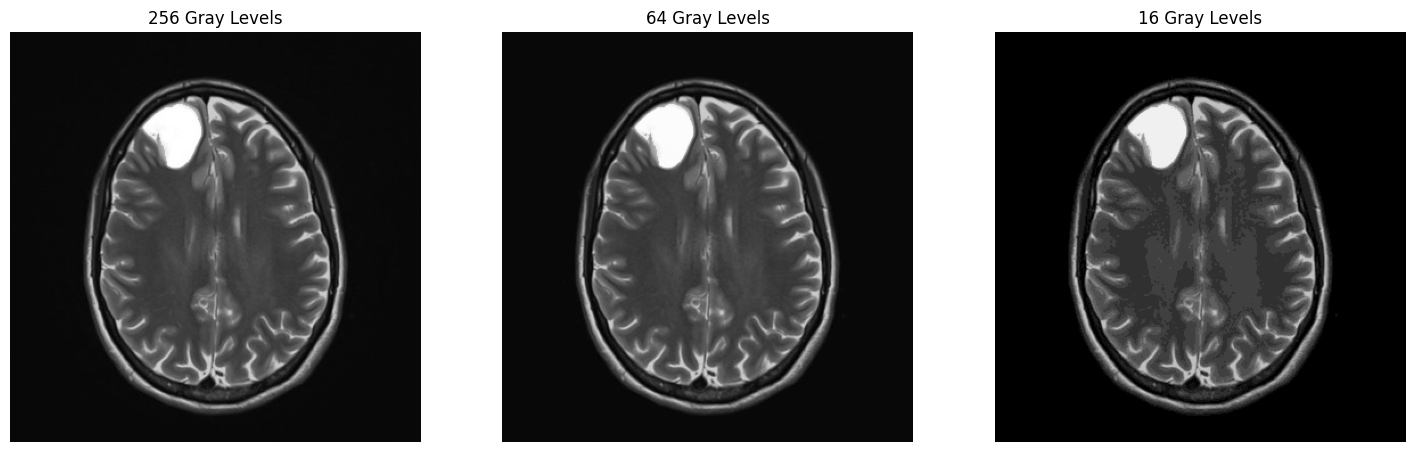

In [5]:
# Project 2 Grey Image

import scipy.io as sio
# 读取 .mat 文件
mat_path = r"D:\课程\专业课\生物医学图像处理\lab1\lab1.mat"
mat_data = sio.loadmat(mat_path)

# 查看变量
print(mat_data.keys())  # dict_keys(['__header__', '__version__', '__globals__', 'data'])

# 取出实际图像数组
image_struct = mat_data['data']

# 如果是嵌套数组（常见结构），取第一个元素
if isinstance(image_struct, np.ndarray) and image_struct.dtype == 'object':
    image = image_struct[0, 0]  # 提取真实图像
else:
    image = image_struct

print("Image shape:", image.shape)

# 定义灰度量化函数
def reduce_gray_levels(img, n):
    """
    将灰度图像量化为 2^n 个灰度级
    img: 输入图像 (np.ndarray)
    n: 灰度级参数，灰度级数为 2^n
    返回量化后的图像
    """
    levels = 2 ** n
    step = 256 // levels  # 每个灰度级的步长
    img_out = (img // step) * step
    return img_out.astype(np.uint8)

# 生成不同灰度级的图像
img_256 = reduce_gray_levels(image, 8)   # 256级灰度
img_64  = reduce_gray_levels(image, 6)   # 64级灰度
img_16  = reduce_gray_levels(image, 4)   # 16级灰度

# 显示图像
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_256, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('256 Gray Levels')
axes[0].axis('off')

axes[1].imshow(img_64, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('64 Gray Levels')
axes[1].axis('off')

axes[2].imshow(img_16, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('16 Gray Levels')
axes[2].axis('off')

plt.show()

可以很明显的看到16级灰度的图像不是很清晰，但是凭借肉眼观察，感觉256级灰度和64级灰度图像的差异不是很大

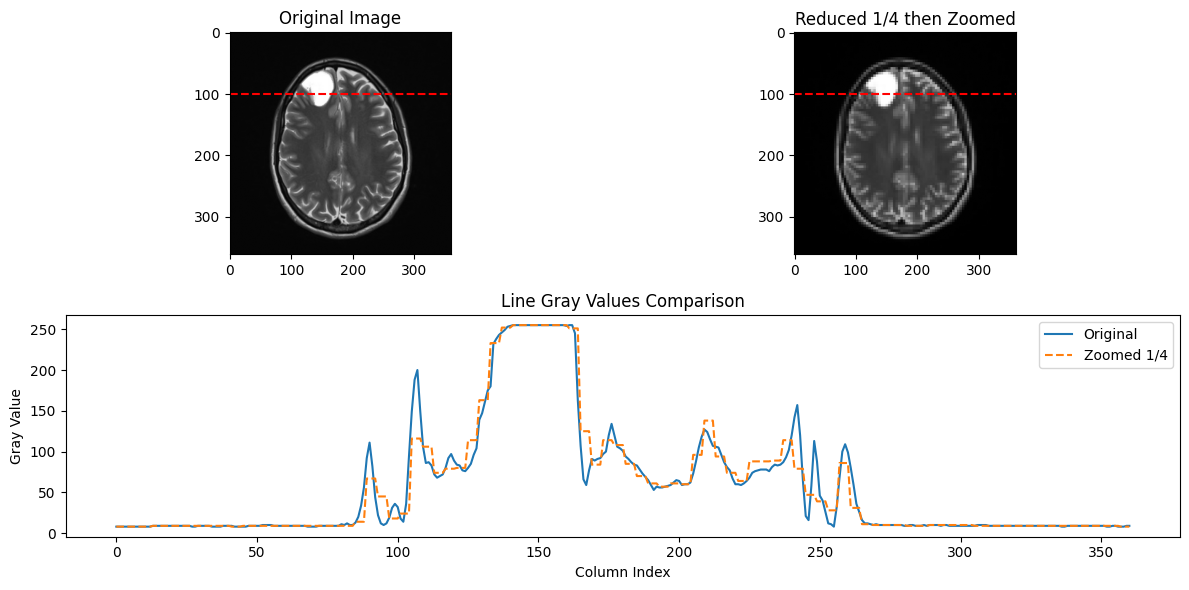

In [6]:
# Project 3 Grey Image
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import cv2  # 用于缩放操作

# 参数设置
mat_path = r"D:\课程\专业课\生物医学图像处理\lab1\lab1.mat"
line_row = 100  # 比较的行
N = 4           # 缩小/放大倍数

# 读取 .mat 文件
mat = sio.loadmat(mat_path)
if 'data' in mat:
    img = mat['data']
else:
    print(mat.keys())
    raise ValueError("请确认 .mat 文件里图像变量名")

# 确保是二维灰度图
img = np.array(img, dtype=np.uint8)
height, width = img.shape

# 提取一行灰度值
original_line = img[line_row, :]

# 缩小图像
small_img = cv2.resize(img, (width//N, height//N), interpolation=cv2.INTER_AREA)

# 放大回原大小
# -----------------------
zoomed_img = cv2.resize(small_img, (width, height), interpolation=cv2.INTER_NEAREST)

# 提取缩放后图像的同一行灰度值
zoomed_line = zoomed_img[line_row, :]

# 可视化对比
plt.figure(figsize=(12, 6))

# 原图
plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axhline(y=line_row, color='r', linestyle='--')  # 标出比较行

# 缩小后再放大图
plt.subplot(2, 2, 2)
plt.title(f"Reduced 1/{N} then Zoomed")
plt.imshow(zoomed_img, cmap='gray')
plt.axhline(y=line_row, color='r', linestyle='--')

# 灰度值对比
plt.subplot(2, 1, 2)
plt.title("Line Gray Values Comparison")
plt.plot(original_line, label="Original")
plt.plot(zoomed_line, label=f"Zoomed 1/{N}", linestyle='--')
plt.xlabel("Column Index")
plt.ylabel("Gray Value")
plt.legend()

plt.tight_layout()
plt.show()

选取了和PPT上不一样的一条线进行观察，发现处理过后的图像变得模糊，

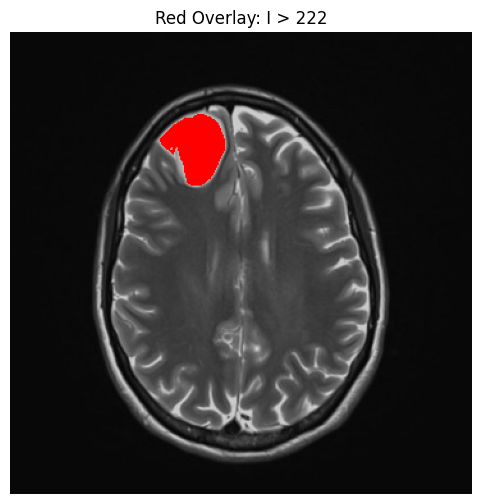

In [7]:
# Project 4 Color Image
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
mat_path = r"D:\课程\专业课\生物医学图像处理\lab1\lab1.mat"
threshold = 222  # Color Overlay 阈值

# 读取 .mat 文件
mat = sio.loadmat(mat_path)
if 'data' in mat:
    img = mat['data']
else:
    print(mat.keys())
    raise ValueError("请确认 .mat 文件里图像变量名")

# 确保是二维灰度图
img = np.array(img, dtype=np.uint8)

# Color Overlay
# 生成 mask
mask = img > threshold  # 大于阈值的像素为 True

# 转成 3 通道彩色图
color_img = np.stack([img, img, img], axis=-1)

# mask 放入红色通道
color_img[mask, 0] = 255  # 红色通道
color_img[mask, 1] = 0  # 保留绿色
color_img[mask, 2] = 0  # 保留蓝色

# 可视化彩色叠加
plt.figure(figsize=(6, 6))
plt.imshow(color_img)
plt.title(f"Red Overlay: I > {threshold}")
plt.axis('off')
plt.show()